In [2]:
import sys
from pathlib import Path

# Ajouter la racine du projet au sys.path de Python
PROJECT_ROOT = (
    Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform
from sklearn.metrics import roc_auc_score

from src.config import FIGURES_DIR
from src.data.split import get_train_val
from src.utils.seeds import set_seed

set_seed()
X_fit, X_val, y_fit, y_val = get_train_val()
print(f"Données d'apprentissage chargées : {X_fit.shape}")

2026-08-20 22:30:55.857367: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-20 22:30:55.908095: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Données d'apprentissage chargées : (48000, 170)


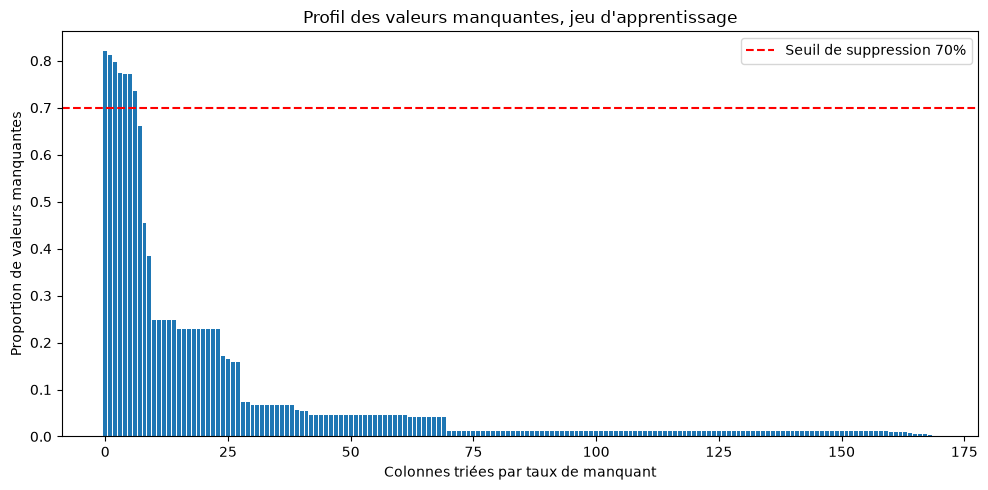

In [3]:
missing_ratio = X_fit.isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(missing_ratio)), missing_ratio.values)
ax.axhline(0.70, color="red", linestyle="--", label="Seuil de suppression 70%")
ax.set_xlabel("Colonnes triées par taux de manquant")
ax.set_ylabel("Proportion de valeurs manquantes")
ax.set_title("Profil des valeurs manquantes, jeu d'apprentissage")
ax.legend()
fig.tight_layout()

# Sauvegarde pour le rapport et affichage dans le notebook
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / "fig01_missing_profile.png", dpi=150)
plt.show()

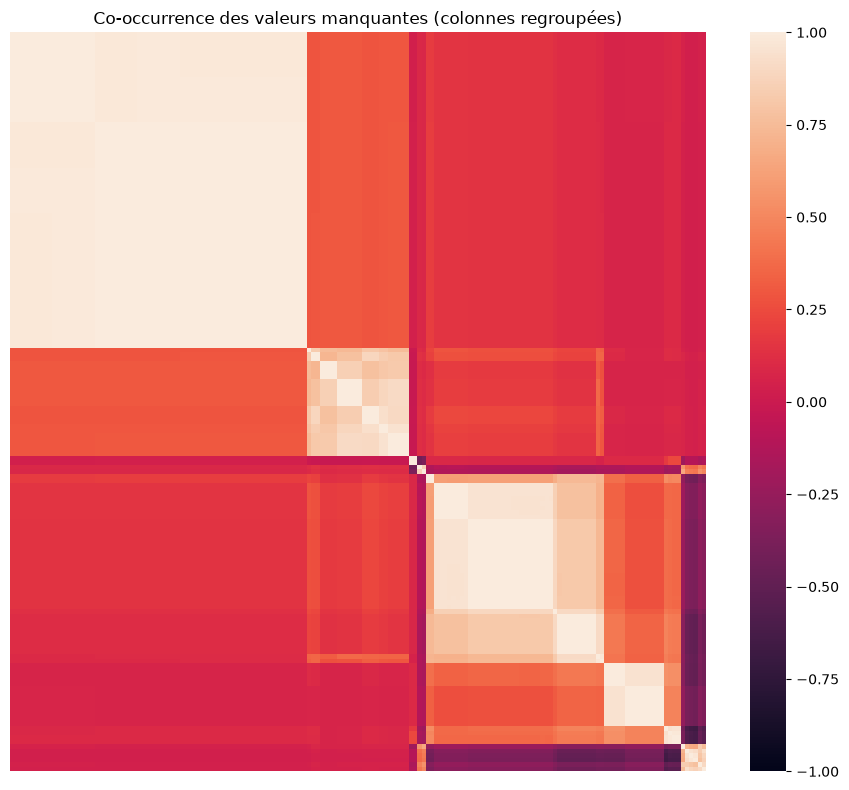

In [4]:
indicators = X_fit.isna().astype(int)
indicators = indicators.loc[:, indicators.mean().between(0.01, 0.99)]

corr = indicators.corr().fillna(0)
distance = squareform(1 - corr.abs().values, checks=False)
order = leaves_list(linkage(distance, method="average"))
corr_ordered = corr.iloc[order, order]

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    corr_ordered,
    cmap="rocket",
    vmin=-1,
    vmax=1,
    xticklabels=False,
    yticklabels=False,
    ax=ax,
)
ax.set_title("Co-occurrence des valeurs manquantes (colonnes regroupées)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig02_missing_blocks.png", dpi=150)
plt.show()

In [5]:
informative = {}
for col in X_fit.columns:
    flag = X_fit[col].isna().astype(int)
    if 0.01 < flag.mean() < 0.99:
        informative[col] = roc_auc_score(y_fit, flag)

scores = pd.Series(informative).sort_values(ascending=False)
print("Top 10 des colonnes dont l'absence est la plus liée aux pannes (AUC) :")
print(scores.head(10).round(3))

Top 10 des colonnes dont l'absence est la plus liée aux pannes (AUC) :
di_000    0.729
dk_000    0.729
eb_000    0.729
dh_000    0.729
dj_000    0.729
dl_000    0.729
dm_000    0.729
df_000    0.729
dg_000    0.729
ak_000    0.729
dtype: float64


In [6]:
n_unique = X_fit.nunique(dropna=True)
constant = n_unique[n_unique <= 1].index.tolist()

dominant_share = X_fit.apply(
    lambda s: (
        s.value_counts(normalize=True, dropna=True).max()
        if s.notna().any()
        else 1.0
    )
)
quasi_constant = dominant_share[dominant_share > 0.999].index.tolist()

print(f"Colonnes constantes      : {len(constant)} -> {constant}")
print(
    f"Colonnes quasi-constantes : {len(quasi_constant)} -> {quasi_constant}"
)

Colonnes constantes      : 1 -> ['cd_000']
Colonnes quasi-constantes : 3 -> ['as_000', 'cd_000', 'ch_000']


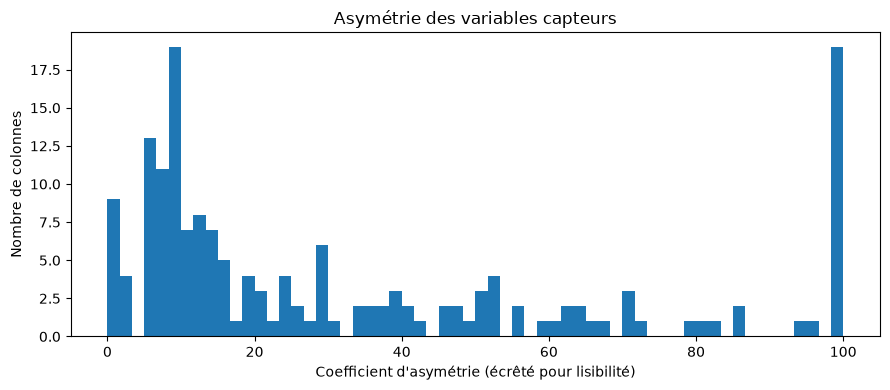

Colonnes d'asymétrie > 5 : 157 sur 170


In [7]:
skewness = X_fit.skew(numeric_only=True).dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(skewness.clip(-20, 100), bins=60)
ax.set_xlabel("Coefficient d'asymétrie (écrêté pour lisibilité)")
ax.set_ylabel("Nombre de colonnes")
ax.set_title("Asymétrie des variables capteurs")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig03_skewness.png", dpi=150)
plt.show()

print(f"Colonnes d'asymétrie > 5 : {(skewness > 5).sum()} sur {len(skewness)}")

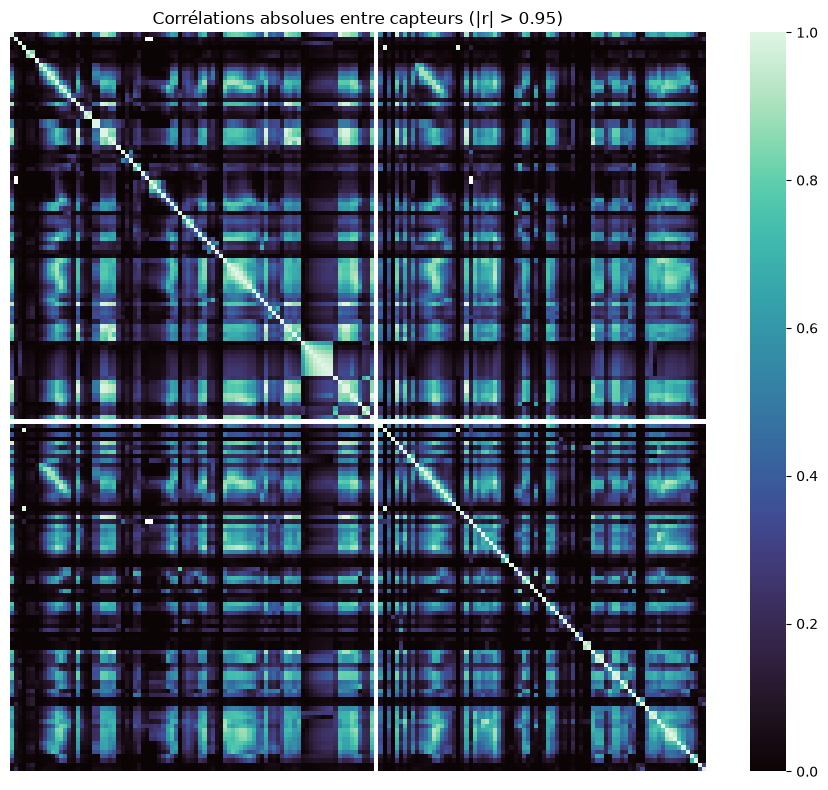

Colonnes redondantes (|r| > 0.95) : 26


In [8]:
from src.config import CORRELATION_THRESHOLD

corr_matrix = X_fit.corr(numeric_only=True).abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
redundant = [
    c for c in upper.columns if (upper[c] > CORRELATION_THRESHOLD).any()
]

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    corr_matrix,
    cmap="mako",
    vmin=0,
    vmax=1,
    xticklabels=False,
    yticklabels=False,
    ax=ax,
)
ax.set_title(
    f"Corrélations absolues entre capteurs (|r| > {CORRELATION_THRESHOLD})"
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig04_correlation.png", dpi=150)
plt.show()

print(f"Colonnes redondantes (|r| > {CORRELATION_THRESHOLD}) : {len(redundant)}")

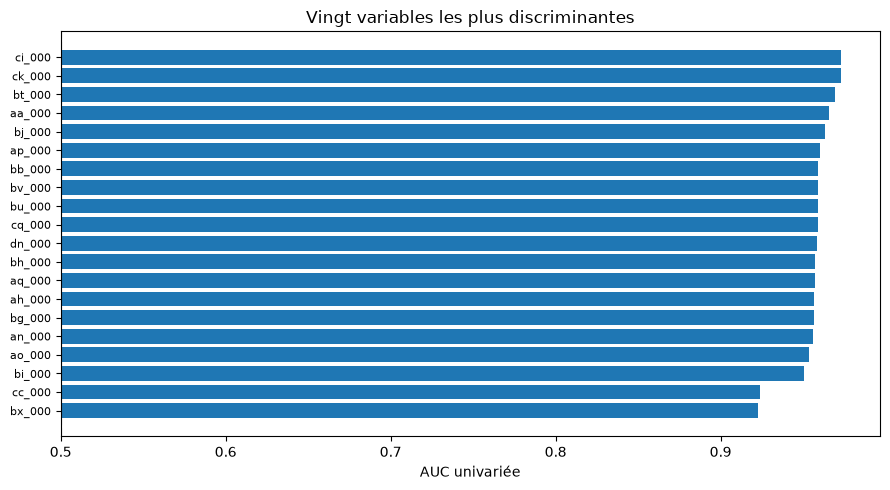

Top 10 des variables les plus discriminantes :
ci_000    0.973
ck_000    0.973
bt_000    0.969
aa_000    0.966
bj_000    0.963
ap_000    0.960
bb_000    0.959
bv_000    0.959
bu_000    0.959
cq_000    0.959
dtype: float64


In [9]:
univariate_auc = {}
for col in X_fit.columns:
    mask = X_fit[col].notna()
    if mask.sum() > 100 and y_fit[mask].nunique() == 2:
        univariate_auc[col] = roc_auc_score(y_fit[mask], X_fit.loc[mask, col])

auc_series = pd.Series(univariate_auc)
strength = (auc_series - 0.5).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
top = strength.head(20).index[::-1]
ax.barh(range(len(top)), auc_series[top].values - 0.5, left=0.5)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top, fontsize=8)
ax.axvline(0.5, color="grey", linestyle="--")
ax.set_xlabel("AUC univariée")
ax.set_title("Vingt variables les plus discriminantes")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig05_univariate_auc.png", dpi=150)
plt.show()

print("Top 10 des variables les plus discriminantes :")
print(auc_series[strength.head(10).index].round(3))

In [10]:
from src.features.histograms import HistogramFeatures

# Transformation
hist_transformer = HistogramFeatures(keep_raw_bins=True)
X_trans = hist_transformer.fit_transform(X_fit)

print(
    f"Forme initiale : {X_fit.shape} | Forme après feature engineering : {X_trans.shape}"
)
print(f"Groupes d'histogrammes détectés : {list(hist_transformer.groups_.keys())}")

# Evaluation de l'AUC univariée des 42 nouvelles variables
new_cols = [c for c in X_trans.columns if c not in X_fit.columns]

derived_auc = {}
for col in new_cols:
    mask = X_trans[col].notna()
    if mask.sum() > 100 and y_fit[mask].nunique() == 2:
        derived_auc[col] = roc_auc_score(y_fit[mask], X_trans.loc[mask, col])

print(
    "\nTop 10 des variables dérivées les plus discriminantes (AUC univariée) :"
)
print(pd.Series(derived_auc).sort_values(ascending=False).round(3).head(10))

/home/lady_horacia/pdm-aps-scania/src/features/histograms.py:58: RuntimeWarning: All-NaN slice encountered
  derived[f"{prefix}_max_share"] = np.nanmax(shares, axis=1)
/home/lady_horacia/pdm-aps-scania/src/features/histograms.py:58: RuntimeWarning: All-NaN slice encountered
  derived[f"{prefix}_max_share"] = np.nanmax(shares, axis=1)
/home/lady_horacia/pdm-aps-scania/src/features/histograms.py:58: RuntimeWarning: All-NaN slice encountered
  derived[f"{prefix}_max_share"] = np.nanmax(shares, axis=1)
/home/lady_horacia/pdm-aps-scania/src/features/histograms.py:58: RuntimeWarning: All-NaN slice encountered
  derived[f"{prefix}_max_share"] = np.nanmax(shares, axis=1)
/home/lady_horacia/pdm-aps-scania/src/features/histograms.py:58: RuntimeWarning: All-NaN slice encountered
  derived[f"{prefix}_max_share"] = np.nanmax(shares, axis=1)
/home/lady_horacia/pdm-aps-scania/src/features/histograms.py:58: RuntimeWarning: All-NaN slice encountered
  derived[f"{prefix}_max_share"] = np.nanmax(shares, 

Forme initiale : (48000, 170) | Forme après feature engineering : (48000, 212)
Groupes d'histogrammes détectés : ['ag', 'ay', 'az', 'ba', 'cn', 'cs', 'ee']

Top 10 des variables dérivées les plus discriminantes (AUC univariée) :
ay_total         0.905
ee_total         0.905
az_total         0.905
ba_total         0.905
cn_total         0.905
ag_total         0.905
cs_total         0.905
ag_entropy       0.805
ag_std_rank      0.788
cn_tail_ratio    0.768
dtype: float64


In [11]:
hist_features = HistogramFeatures(keep_raw_bins=False).fit_transform(X_fit)
new_cols = [c for c in hist_features.columns if c not in X_fit.columns]

derived_auc = {}
for col in new_cols:
    mask = hist_features[col].notna()
    if mask.sum() > 100 and y_fit[mask].nunique() == 2:
        derived_auc[col] = roc_auc_score(y_fit[mask], hist_features.loc[mask, col])

print("AUC univariee des variables derivees :")
print(pd.Series(derived_auc).sort_values(ascending=False).round(3).head(15))

/home/lady_horacia/pdm-aps-scania/src/features/histograms.py:58: RuntimeWarning: All-NaN slice encountered
  derived[f"{prefix}_max_share"] = np.nanmax(shares, axis=1)
/home/lady_horacia/pdm-aps-scania/src/features/histograms.py:58: RuntimeWarning: All-NaN slice encountered
  derived[f"{prefix}_max_share"] = np.nanmax(shares, axis=1)
/home/lady_horacia/pdm-aps-scania/src/features/histograms.py:58: RuntimeWarning: All-NaN slice encountered
  derived[f"{prefix}_max_share"] = np.nanmax(shares, axis=1)
/home/lady_horacia/pdm-aps-scania/src/features/histograms.py:58: RuntimeWarning: All-NaN slice encountered
  derived[f"{prefix}_max_share"] = np.nanmax(shares, axis=1)
/home/lady_horacia/pdm-aps-scania/src/features/histograms.py:58: RuntimeWarning: All-NaN slice encountered
  derived[f"{prefix}_max_share"] = np.nanmax(shares, axis=1)
/home/lady_horacia/pdm-aps-scania/src/features/histograms.py:58: RuntimeWarning: All-NaN slice encountered
  derived[f"{prefix}_max_share"] = np.nanmax(shares, 

AUC univariee des variables derivees :
ay_total         0.905
ee_total         0.905
az_total         0.905
ba_total         0.905
cn_total         0.905
ag_total         0.905
cs_total         0.905
ag_entropy       0.805
ag_std_rank      0.788
cn_tail_ratio    0.768
cn_entropy       0.754
cn_std_rank      0.729
ba_entropy       0.691
ba_mean_rank     0.656
ay_tail_ratio    0.650
dtype: float64
